# Conceptos Básicos de Machine Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/01_introduccion/01_conceptos_basicos.ipynb)

## Objetivos
- Comprender las diferencias fundamentales entre Inteligencia Artificial, Machine Learning y Deep Learning.
- Identificar los principales tipos de aprendizaje (Supervisado, No Supervisado, por Refuerzo).
- Asentar la terminología básica (*Features*, *Target*, *Training Set*, *Test Set*).

## Prerrequisitos
- Conocimientos básicos de programación en Python.
- Nociones elementales de álgebra y estadística.

---
## Configuración del Entorno

In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    sys.path.append(f"/content/{REPO_NAME}")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

In [1]:
# Importación de librerías generales
import matplotlib.pyplot as plt
import numpy as np

## 1. IA vs Machine Learning vs Deep Learning

A menudo estos términos se usan como sinónimos en medios no técnicos, pero en ingeniería es vital diferenciarlos:

*   **Inteligencia Artificial (IA):** El campo más amplio. Cualquier técnica que permita a las computadoras imitar la inteligencia humana. Incluye desde sistemas de reglas ("Si X, entonces Y") hasta redes neuronales.
*   **Machine Learning (ML):** Un subcampo de la IA. Consiste en algoritmos que *aprenden* patrones a partir de datos sin ser explícitamente programados para la tarea. Mejoran su rendimiento con la experiencia.
*   **Deep Learning (DL):** Un subcampo del ML basado en Redes Neuronales Artificiales con múltiples capas (profundas). Excelente para datos no estructurados como imágenes, audio o texto natural.

### Analogía Práctica
Supongamos que tenemos la tarea de crear un filtro de spam para correos electrónicos.
- **Enfoque Clásico (No ML):** Programas reglas a mano: `SI el correo contiene "ganaste un viaje a Cancún" -> ENTONCES es Spam`. *Problema: Hay que actualizar las reglas constantemente.*
- **Enfoque Machine Learning:** Le das al algoritmo miles de correos etiquetados como "Spam" o "No Spam". El algoritmo analiza la frecuencia de las palabras y *aprende* estadísticamente qué hace que un correo sea spam.
- **Enfoque Deep Learning:** Usarías una red neuronal procesando el texto completo, capturando no solo palabras aisladas sino el contexto semántico de las frases.

## 2. Tipos de Machine Learning

Existen tres paradigmas principales de aprendizaje, categorizados según la naturaleza de los datos disponibles.

### Aprendizaje Supervisado (*Supervised Learning*)
El algoritmo aprende de un conjunto de datos **etiquetados**. Es decir, para cada ejemplo de entrada (*features*), le proporcionamos la respuesta correcta (*target*).
- **Ejemplo:** Predecir el precio de una casa (Target: numérico) basándonos en su tamaño, ubicación y número de habitaciones (Features).
- **Subcategorías:** Clasificación (predecir categorías, ej. Spam/No Spam) y Regresión (predecir números continuos).

### Aprendizaje No Supervisado (*Unsupervised Learning*)
Los datos de entrada **no tienen etiquetas**. El algoritmo debe encontrar estructuras ocultas o patrones por sí mismo.
- **Ejemplo:** Agrupar clientes de un banco según sus hábitos de compra (Clustering) sin saber de antemano cuántos o qué grupos existen.

### Aprendizaje por Refuerzo (*Reinforcement Learning*)
Un *agente* aprende a comportarse en un *entorno* realizando acciones y recibiendo *recompensas* o *castigos*.
- **Ejemplo:** Entrenar a una IA para jugar al ajedrez o enseñar a un robot a caminar.

## 3. Terminología Clave en Ingeniería de Datos

Para comunicarnos efectivamente, debemos estandarizar el vocabulario:

*   **Dataset:** Conjunto de datos tabulares. Cada fila es una *Observación* o *Instancia*.
*   **Features (Características / Variables Independientes):** Las columnas usadas para predecir. Tradicionalmente denotadas como la matriz **X**.
*   **Target (Variable Objetivo / Etiqueta):** Lo que queremos predecir. Denotada como el vector **y**.
*   **Training Set (Conjunto de Entrenamiento):** Subconjunto de datos (usualmente 70-80%) usado para entrenar o ajustar el modelo.
*   **Test Set (Conjunto de Prueba):** Subconjunto de datos "oculto" al modelo durante el entrenamiento. Se usa al final para evaluar cómo generaliza el modelo ante datos *nunca antes vistos*.

### ¿Por qué dividimos en Train y Test?
Si evaluamos el modelo con los mismos datos con los que aprendió, corremos el riesgo de sufrir **Overfitting (Sobreajuste)**. Es como darle las respuestas del examen a un estudiante el día antes: sacará un 10, pero no sabrá resolver problemas nuevos en la vida real.

## 4. Visualización de Overfitting vs Buen Ajuste

Generemos un ejemplo visual de por qué "el modelo más complejo" no siempre es el mejor.

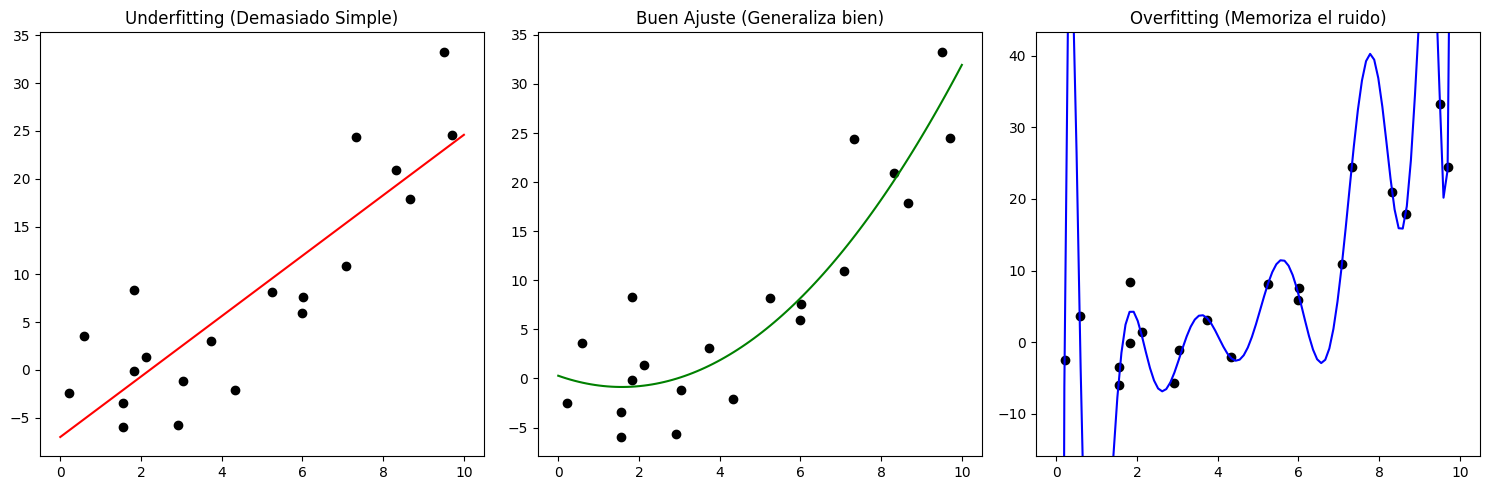

In [2]:
# Generamos datos ruidosos que siguen una tendencia cuadrática
np.random.seed(42)
X = np.sort(np.random.rand(20) * 10)
y = 0.5 * X**2 - 2 * X + 3 + np.random.randn(20) * 5

# Ajustamos diferentes polinomios
# Grado 1: Underfitting (Línea recta)
z1 = np.polyfit(X, y, 1)
p1 = np.poly1d(z1)

# Grado 2: "Just right" (Cuadrática)
z2 = np.polyfit(X, y, 2)
p2 = np.poly1d(z2)

# Grado 15: Overfitting (Curva loca que pasa por cada punto)
z15 = np.polyfit(X, y, 15)
p15 = np.poly1d(z15)

X_plot = np.linspace(0, 10, 100)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color='black')
plt.plot(X_plot, p1(X_plot), color='red')
plt.title('Underfitting (Demasiado Simple)')

plt.subplot(1, 3, 2)
plt.scatter(X, y, color='black')
plt.plot(X_plot, p2(X_plot), color='green')
plt.title('Buen Ajuste (Generaliza bien)')

plt.subplot(1, 3, 3)
plt.scatter(X, y, color='black')
plt.plot(X_plot, p15(X_plot), color='blue')
plt.title('Overfitting (Memoriza el ruido)')
plt.ylim(min(y)-10, max(y)+10)

plt.tight_layout()
plt.show()

## Resultados y Discusión

Como vemos en la gráfica:
- El modelo de la izquierda (línea roja) sufre de **Underfitting (Subajuste)**. Es demasiado rígido y no captura la verdadera relación de los datos. Tendrá errores altos tanto en el entrenamiento como en producción.
- El modelo de la derecha (línea azul) sufre de **Overfitting (Sobreajuste)**. Es tan flexible que pasa exactamente por todos los puntos de entrenamiento, aprendiendo el ruido aleatorio. Si le damos un dato nuevo (fuera de esos puntos exactos), su predicción será desastrosa.
- El modelo central (línea verde) representa el **balance ideal**. Captura la tendencia subyacente sin enloquecer por el ruido.

## Conexiones y Próximos Pasos
- ➡️ **Siguiente:** Con estos conceptos claros, es hora de poner las manos en datos reales. Continuemos con [Introducción al Análisis Exploratorio de Datos (EDA)](../02_eda/01_introduccion_eda.ipynb).

## Referencias
1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.

---
## Entorno de Ejecución

In [ ]:
from utils.environment import environment_table
environment_table()